<a href="https://colab.research.google.com/github/nikimajithiya83/AI-based-power-prediction-for-VLSI-circuits/blob/main/CircuitNet_Power_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, tarfile
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt

print("All imports done!")

Mounted at /content/drive
All imports done!


In [ ]:
csv_path = '/content/drive/MyDrive/power_dataset.csv'  # Moved to root of MyDrive

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"✅ Loaded existing dataset: {df.shape}")
else:
    print("First time setup - extracting data...")
    ir_path = '/content/drive/MyDrive/CircuitNet-N28/IR_drop_features'
    extract_path = '/content/CircuitNet_data'
    os.makedirs(extract_path, exist_ok=True)

    with tarfile.open(f'{ir_path}/IR_drop.tar.gz', 'r:gz') as tar:
        tar.extractall(extract_path)
    print("Extraction done!")

    ir_drop_path = '/content/CircuitNet_data/IR_drop'
    records = []
    for fname in tqdm(os.listdir(ir_drop_path)):
        fpath = f'{ir_drop_path}/{fname}'
        parts = fname.split('-')
        try:
            data = np.load(fpath)
            records.append({
                'design_name':  parts[1],
                'variant':      parts[2],
                'macros':       int(parts[3]),
                'clock_ns':     int(parts[4].replace('c','')),
                'utilization':  float(parts[5].replace('u','')),
                'macro_place':  int(parts[6].replace('m','')),
                'power_mesh':   int(parts[7].replace('p','')),
                'filler':       int(parts[8].replace('f','')),
                'mean_ir_drop': data.mean(),
                'max_ir_drop':  data.max(),
                'std_ir_drop':  data.std(),
                'p90_ir_drop':  np.percentile(data, 90),
                'p99_ir_drop':  np.percentile(data, 99),
                'hotspot_pct':  (data > data.mean() + 2*data.std()).mean(),
            })
        except:
            pass

    df = pd.DataFrame(records)
    df.to_csv(csv_path, index=False)  # Save to root MyDrive
    df.to_csv('/content/power_dataset.csv', index=False)  # Backup in /content
    print(f"✅ Dataset built and saved: {df.shape}")

First time setup - extracting data...


/tmp/ipykernel_2093/568504839.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


Extraction done!


100%|██████████| 10242/10242 [00:44<00:00, 230.93it/s]


✅ Dataset built and saved: (3860, 14)


In [ ]:
le_design  = LabelEncoder()
le_variant = LabelEncoder()
df['design_encoded']  = le_design.fit_transform(df['design_name'])
df['variant_encoded'] = le_variant.fit_transform(df['variant'])

feature_cols = [
    'design_encoded', 'variant_encoded', 'macros', 'clock_ns',
    'utilization', 'macro_place', 'power_mesh', 'filler'
]

X = df[feature_cols]
y = df['mean_ir_drop']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training Random Forest...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(f"✅ Random Forest → R²: {r2_score(y_test, rf_pred):.4f} | MAE: {mean_absolute_error(y_test, rf_pred):.4f}")

print("Training Gradient Boosting...")
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
print(f"✅ Gradient Boosting → R²: {r2_score(y_test, gb_pred):.4f} | MAE: {mean_absolute_error(y_test, gb_pred):.4f}")

Training Random Forest...
✅ Random Forest → R²: 0.6996 | MAE: 0.0335
Training Gradient Boosting...
✅ Gradient Boosting → R²: 0.6837 | MAE: 0.0356


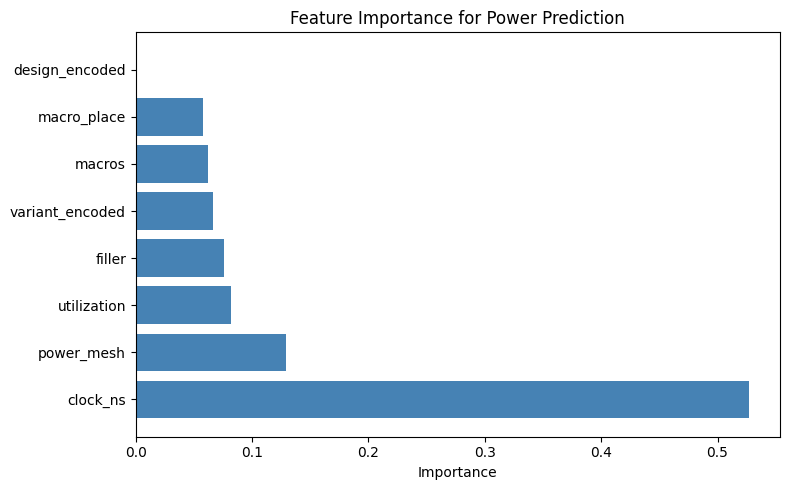

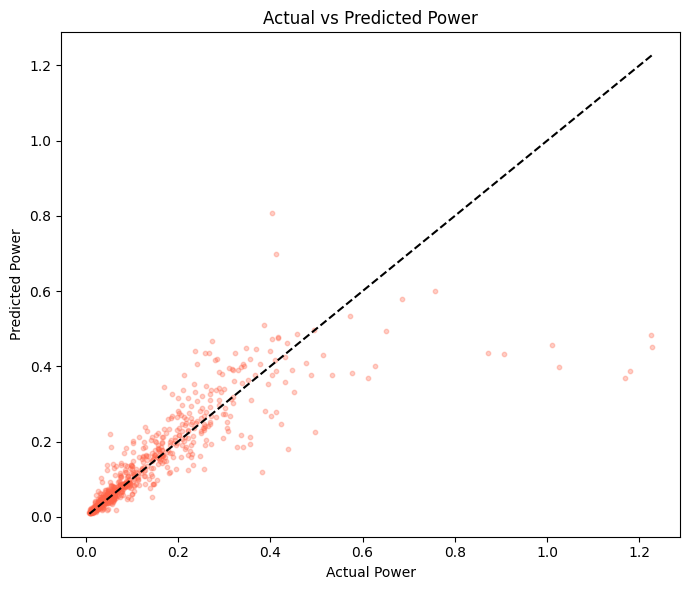

In [ ]:
# Feature Importance
importances = rf.feature_importances_
feat_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(8,5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance for Power Prediction')
plt.tight_layout()
plt.savefig('/content/feature_importance.png')  # Fixed path
plt.show()

# Actual vs Predicted
plt.figure(figsize=(7,6))
plt.scatter(y_test, rf_pred, alpha=0.3, s=10, color='tomato')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1.5)
plt.xlabel('Actual Power')
plt.ylabel('Predicted Power')
plt.title('Actual vs Predicted Power')
plt.tight_layout()
plt.savefig('/content/actual_vs_predicted.png')  # Fixed path
plt.show()

In [ ]:
df['predicted_power'] = rf.predict(X)

print("=" * 60)
print("      POWER DISSIPATION PREDICTION REPORT")
print("=" * 60)
print(f"\n📊 Total designs : {len(df)}")
print(f"   Mean power    : {df['predicted_power'].mean():.4f}")
print(f"   Max power     : {df['predicted_power'].max():.4f}")

threshold_95 = df['predicted_power'].quantile(0.95)
hotspots = df[df['predicted_power'] >= threshold_95]
print(f"\n🔴 Top 5% Power-Hungry Designs ({len(hotspots)}):")
print(hotspots[['design_name','clock_ns','utilization',
                 'power_mesh','predicted_power']].head(10).to_string())

print(f"\n📈 Avg Power by Design Type:")
print(df.groupby('design_name')['predicted_power'].mean().sort_values(ascending=False))

print(f"\n📈 Avg Power by Clock Speed:")
print(df.groupby('clock_ns')['predicted_power'].mean().sort_values(ascending=False))

# Predict new design
def recommend(design_params):
    d_enc = le_design.transform([design_params['design_name']])[0]
    v_enc = le_variant.transform([design_params['variant']])[0]
    feat = pd.DataFrame([{
        'design_encoded': d_enc, 'variant_encoded': v_enc,
        'macros': design_params['macros'], 'clock_ns': design_params['clock_ns'],
        'utilization': design_params['utilization'],
        'macro_place': design_params['macro_place'],
        'power_mesh': design_params['power_mesh'],
        'filler': design_params['filler'],
    }])
    pred = rf.predict(feat)[0]
    recs = []
    if pred < 0.05:
        level = "🟢 LOW"
        recs.append("Design is power-efficient. No major changes needed.")
    elif pred < 0.15:
        level = "🟡 MODERATE"
        recs.append("Consider clock gating on inactive modules.")
        recs.append("Review utilization — slight reduction may help.")
    else:
        level = "🔴 HIGH"
        recs.append("Apply aggressive clock gating on idle modules.")
        recs.append("Reduce switching activity in datapath modules.")
        recs.append("Use operand isolation to prevent unnecessary toggling.")
        recs.append("Consider reducing clock frequency if timing allows.")
        recs.append("Strengthen power mesh to reduce IR drop.")
    if design_params['clock_ns'] <= 2:
        recs.append("⚡ High-frequency — switching power is dominant.")
    if design_params['utilization'] >= 0.85:
        recs.append("⚡ High utilization — dense placement increases power density.")
    return pred, level, recs

new_design = {
    'design_name': 'RISCY', 'variant': 'a',
    'macros': 3, 'clock_ns': 2, 'utilization': 0.85,
    'macro_place': 2, 'power_mesh': 4, 'filler': 1,
}

pred, level, recs = recommend(new_design)
print("\n" + "=" * 60)
print("        NEW DESIGN PREDICTION")
print("=" * 60)
print(f"  Predicted Power : {pred:.4f}")
print(f"  Power Level     : {level}")
print(f"\n  Recommendations:")
for i, r in enumerate(recs, 1):
    print(f"    {i}. {r}")

      POWER DISSIPATION PREDICTION REPORT

📊 Total designs : 3860
   Mean power    : 0.1185
   Max power     : 1.2757

🔴 Top 5% Power-Hungry Designs (193):
    design_name  clock_ns  utilization  power_mesh  predicted_power
22        RISCY         2         0.75           5         0.456036
30        RISCY         2         0.80           5         0.466337
53        RISCY         2         0.80           1         0.448209
56        RISCY         2         0.90           2         0.399701
67        RISCY         2         0.85           6         0.415850
91        RISCY         2         0.85           2         0.673076
125       RISCY         2         0.85           8         0.390434
155       RISCY         2         0.85           4         0.496622
156       RISCY         2         0.80           2         0.423701
200       RISCY         2         0.70           3         0.585293

📈 Avg Power by Design Type:
design_name
RISCY    0.118522
Name: predicted_power, dtype: float64

In [ ]:
import joblib

# Save model to Google Drive
joblib.dump(rf, '/content/drive/MyDrive/power_prediction_model.pkl')
joblib.dump(le_design, '/content/drive/MyDrive/le_design.pkl')
joblib.dump(le_variant, '/content/drive/MyDrive/le_variant.pkl')
print("✅ Model saved to Google Drive!")

✅ Model saved to Google Drive!
